In [189]:
# set up environment
using Pkg; Pkg.activate(".")
using Random, LinearAlgebra
using Convex, MosekTools
using Plots

  Activating project at `c:\Users\loren\Documents\_Lorenzo\research\bayesiansos`


### Function and Samples
**Function:** We want to model $f: \mathbb{R}^n \rightarrow \mathbb{R}$.<br>
**Data:** $N$ noisy function evaluations $(x_i, y_i \triangleq \tilde{f}(x_i))$ for $i=1,...,N$.

In [217]:
# setup
# function (n = 1)
f(x) = x^2 / 3 - 3 * x * sin(x-2) - cos(x)
domain = [-10, 10]

# data
x_samples = [-9., -7, -5, -3, -1, 1, 3, 5, 7, 9]
N = length(x_samples)
# N = 10
# x_samples = rand(N).*20 .- 10.
σm_generate = 1.0
f̃(x) = f(x) + σm_generate*randn()
y = f̃.(x_samples);

### Kernel
**SOS model:** Model $f \approx \hat f = \phi(x)^T A \phi(x) + c$ for $A \succeq 0$. Parameters of the model are $A$ and $c$. The map $\phi(\cdot)$ is an arbitrary feature map.

We can use the kernel trick to make this finite-dimensional. For data $x_i$, we have:

$$ A = \sum_{i=1}^N \sum_{j=1}^N \phi(x_i) B_{ij} \phi(x_j)^T $$

where $B \in \mathcal{S}^{N}$ and $B \succeq 0$. This gives a finite version of the SOS model:

**Finite SOS model:** $\hat f = v(x)^T B v(x) + c$, where $v(x) = [k(x, x_1),...,k(x,x_N)]^T\in\mathbb{R}^N$ and $k(x, z) = \phi(x) \phi(z)^T$ is a kernel.

In [218]:
# finite SOS model
sk = 1.
σk = 1.8
k(x1, x2) = sk*exp(-((x1-x2)'*(x1-x2)) / (2σk^2))
v(x) = [k(x, xi) for xi in x_samples]
vxi = [v(xi) for xi in x_samples];

### Wishart-Exponential-Gaussian

We model $B$ and $c$ probabilistically in a Bayesian manner.

**Priors:** $P(B)$, $P(c)$<br>
**Likelihood:** $P(y_i | B, c, x_i)$, independent for each $i$.

Using Bayes rule, the posterior is:

$$
P(A, c | x_1, y_1, ..., x_N, y_N) = P(B)P(c)\prod_{i=1}^N P(y_i | B, c, x_i)
$$

**Prior:** $P(B) \sim W_N(V, p)$ (Wishart), $P(c) = \lambda \exp\left(-\lambda(\gamma - c)\right)$ (exponential)<br>
**Likelihood:** $P(y_i | B, c, x_i) \sim \mathcal{N}(v(x_i)^T B v(x_i) + c,\sigma_m^2)$

For $p \geq N + 1$, the Wishart prior has density:

$$
P(B) \propto (\det B)^{(p-N-1)/2}\exp\left(-\frac12 \mathrm{tr}(V^{-1} A)\right)
$$

And the likelihood has density:
$$
P(y_i | B, c, x_i) = \frac{1}{\sqrt{2\pi\sigma_m^2}} \exp\left( -\frac1{2\sigma_m^2} (y_i - v(x_i)^T B v(x_i) - c)^2 \right)
$$

The log-posterior is:
$$
\log P(B, c | y_i, x_i) = \frac{p-N-1}2\log\det B - \frac12 \mathrm{tr}(V^{-1} B) - \lambda (\gamma - c) - \sum_{i=1}^N \frac1{2\sigma_m^2} (y_i \ v(x_i)^T B v(x_i) - c)^2 + \mathrm{const}
$$

This is not a known distribution, but we can calculate its mode using a semidefinite program:
$$
\max \log P(B, c | y_i, x_i)
$$

$$
\begin{aligned}
=\max_{B \succeq 0,\ c}\ & (p-N-1)\log\det B - \mathrm{tr}(V^{-1} B) - \frac1{\sigma_m^2}\sum_{i=1}^N (y_i-z_i -c)^2 - \lambda (\gamma - c)\\
\mathrm{s.t.}\ & z_i = v(x_i)^T B v(x_i)\\
& (\text{implied constraint: } c \leq \gamma)
\end{aligned}
$$

In [196]:
# parameters
Vinv = I(N)
p = N+1
λ = 1.0
σm_likelihood = σm_generate

# optimize to get the mode
B = Semidefinite(N)
c = Variable()
z = Variable(N)
constraints = [z[i] == vxi[i]'*B*vxi[i] for i = 1:N]
objective = (p-N-1)*logdet(B) - tr(Vinv*B) + λ*c - sum([(y[i] - z[i] - c)*(y[i] - z[i] - c) for i = 1:N]) / (σm_likelihood^2)
problem = maximize(objective, constraints)
solve!(problem, Mosek.Optimizer; silent = true)
println("Solved with status: $(problem.status)")

# mode function
B_wcg = evaluate(B)
c_wcg = evaluate(c)
f̂_wcg(x) = v(x)'*B_wcg*v(x) + c_wcg;

MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 59 (nearly) zero elements are specified in sparse row ''(45) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 44 (nearly) zero elements are specified in sparse row ''(46) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 27 (nearly) zero elements are specified in sparse row ''(47) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 10 (nearly) zero elements are specified in sparse row ''(48) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 1 (nearly) zero elements are specified in sparse row ''(49) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 1 (nearly) zero elements are specified in sparse row ''(50) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 10 (nearly) zero elements are specified in sparse row ''(51) of matrix 'A'.
MOSEK warning 705 (MSK_RES_WRN_ZEROS_IN_SPARSE_ROW): 27 (nearly) zero elements are specified in spa

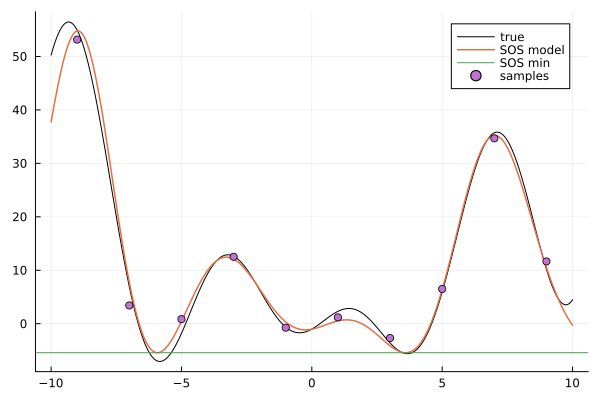

In [207]:
# plot
xdomain = range(1*domain[1], 1*domain[2], length=1000)
Plots.plot(xdomain, f.(xdomain), lc="black", label="true")
Plots.plot!(xdomain, f̂_wcg.(xdomain), lw=1.5, label="SOS model")
Plots.hline!([c_wcg], label="SOS min")
Plots.scatter!(x_samples, y, label="samples")

### MCMC

In [82]:
using Turing
import JuliaBUGS

In [225]:
# TODO: add in gamma?
gam = -15
@model function posterior_wcg(vxi,y, gam)
    B ~ JuliaBUGS.BUGSPrimitives.dwish(inv(Vinv), p)
    # c_gam = -c
    c_gam ~ Turing.Exponential(λ)
    c = gam-c_gam
    for i = 1:length(y)
        y[i] ~ Normal(vxi[i]'*B*vxi[i] - c_gam, σm_likelihood)
    end
end
chain_wcg = sample(posterior_wcg(vxi, y, gam), NUTS(), 1000)

Sampling   0%|█                                         |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\loren\.julia\packages\Turing\4hMHm\src\mcmc\hmc.jl:191
Sampling   1%|█                                         |  ETA: 0:02:58
Sampling   1%|█                                         |  ETA: 0:01:42
Sampling   2%|█                                         |  ETA: 0:02:29
Sampling   2%|█                                         |  ETA: 0:03:04
Sampling   3%|██                                        |  ETA: 0:03:19
Sampling   3%|██                                        |  ETA: 0:03:24
Sampling   4%|██                                        |  ETA: 0:03:47
Sampling   4%|██                                        |  ETA: 0:03:44
Sampling   5%|██                                        |  ETA: 0:03:49
Sampling   5%|███                                       |  ETA: 0:03:45
Sampling   6%|███                                       |  ETA: 0:03:44
Sampling 

╭─FlexiChain (1000 iterations, 1 chain) ───────────────────────────────────────╮
│ ↓ iter  = 501:1500                                                           │
│ → chain = 1:1                                                                │
│                                                                              │
│ Parameters (2) ── AbstractPPL.VarName                                        │
│  Matrix{Float64}  B                                                          │
│  Float64          c_gam                                                      │
│                                                                              │
│ Extras (14)                                                                  │
│  Int64    n_steps, tree_depth                                                │
│  Bool     is_accept, numerical_error                                         │
│  Float64  acceptance_rate, log_density, hamiltonian_energy,                  │
│           hamiltonian_ener

In [226]:
function svec(A)
    n = size(A,1)
    a = zeros(round(Int, n*(n+1)/2))
    k = 1
    for j = 1:n, i = j:n
        # need √2 for off-diag so ⟨A, B⟩ = svec(A)'*svec(B)
        a[k] = A[i,j] * (i == j ? 1. : √2)
        k += 1
    end
    return a
end
function smat(a)
    n = round(Int, (-1 + sqrt(1 + 8*size(a,1)))/2)
    A = zeros(n,n)
    k = 1
    for j = 1:n, i = j:n
        if i == j
            A[i,j] = a[k]
        else
            A[i,j] = A[j,i] = a[k] / (√2)
        end
        k += 1
    end
    return A
end;

In [227]:
B_mean_wcg = mean(chain_wcg[@varname(B)])
c_mean_wcg = -mean(chain_wcg[@varname(c_gam)])

f̂_wcg_mean(x) = v(x)'*B_mean_wcg*v(x) + c_mean_wcg;

# compute standard deviation
c_var_wcg = var(chain_wcg[@varname(c_gam)])
Ac_cov_wcg = -cov(chain_wcg[@varname(B)], chain_wcg[@varname(c_gam)])[1]
vecA_cov_wcg = cov(reduce(hcat,svec.(chain_wcg[@varname(B)])), dims=2)

std_fn_wcg(x) = sqrt(
    2*v(x)'*Ac_cov_wcg*v(x)
    +
    c_var_wcg
    +
    svec(v(x)*v(x)')'*vecA_cov_wcg*svec(v(x)*v(x)')
);

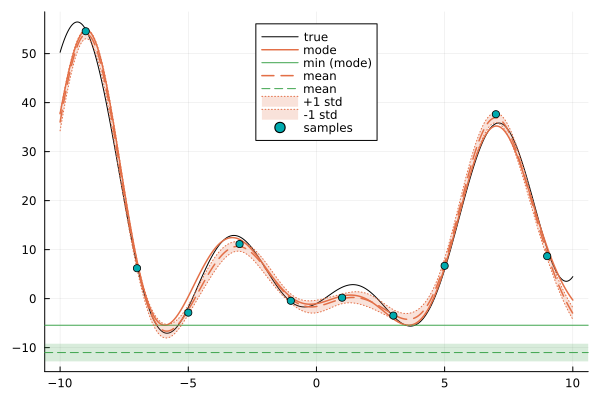

In [241]:
# plot
xdomain = range(1*domain[1], 1*domain[2], length=1000)
Plots.plot(xdomain, f.(xdomain), lc="black", label="true")
Plots.plot!(font="helvetica",legend=:top)

# mode
Plots.plot!(xdomain, f̂_wcg.(xdomain), lw=1.5, label="mode", c=2)
Plots.hline!([c_wcg], label="min (mode)", c=3)

# mean
Plots.plot!(xdomain, f̂_wcg_mean.(xdomain), lw=1.5, label="mean", c=2, ls=:dash)
Plots.hline!([c_mean_wcg], ribbon=sqrt(c_var_wcg), fillalpha = 0.2, label="mean", c=3, ls=:dash)
f_p1std(x) = f̂_wcg_mean(x) + std_fn_wcg(x)
f_m1std(x) = f̂_wcg_mean(x) - std_fn_wcg(x)
Plots.plot!(xdomain, f_p1std.(xdomain), fillrange=f̂_wcg_mean.(xdomain), fillalpha=0.2, c=2, ls=:dot, label="+1 std")
Plots.plot!(xdomain, f_m1std.(xdomain), fillrange=f̂_wcg_mean.(xdomain), fillalpha=0.2, c=2, ls=:dot, label="-1 std")

Plots.scatter!(x_samples, y, label="samples", c=6)